(200, 2) (200, 1)


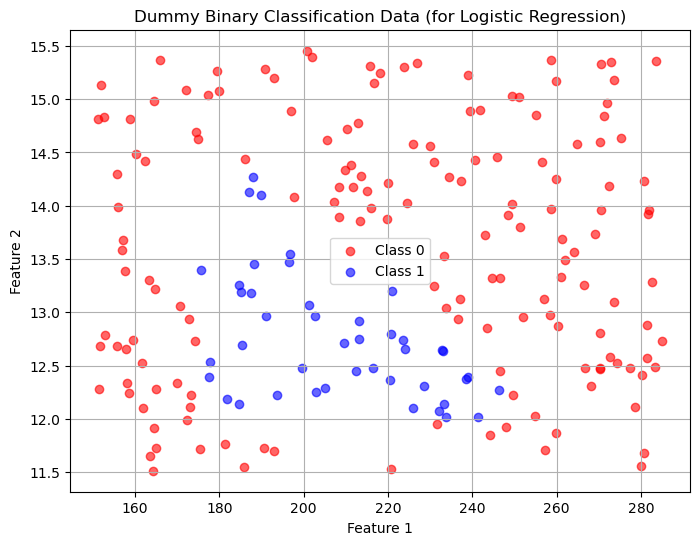

In [49]:
import numpy as np
from matplotlib import pyplot as plt

def load_coffee_data():
    """ Creates a coffee roasting data set.
        roasting duration: 12-15 minutes is best
        temperature range: 175-260C is best
    """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1,2)
    X[:,1] = X[:,1] * 4 + 11.5          # 12-15 min is best
    X[:,0] = X[:,0] * (285-150) + 150  # 350-500 F (175-260 C) is best
    Y = np.zeros(len(X))
    
    i=0
    for t,d in X:
        y = -3/(260-175)*t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d<=y ):
            Y[i] = 1
        else:
            Y[i] = 0
        i += 1

    return (X, Y.reshape(-1,1))

X,y = load_coffee_data()
print(X.shape, y.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X[y.flatten() == 0][:, 0], X[y.flatten() == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(X[y.flatten() == 1][:, 0], X[y.flatten() == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

(200, 2)


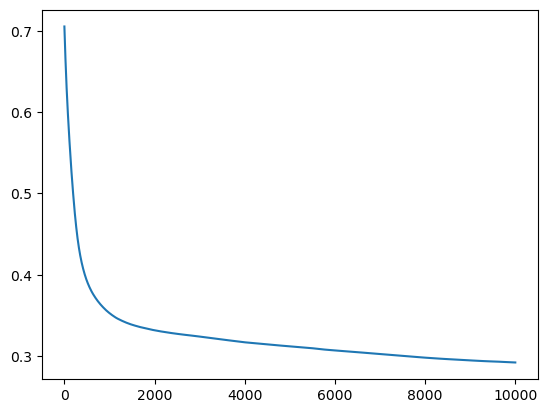

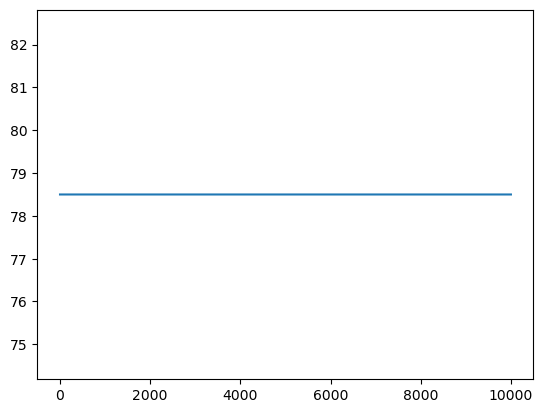

In [55]:
#normalize the data 
X = (X - X.mean(axis=0))/ X.std(axis=0)
neurons_layer = [4,2,3,1]
activation = ('relu','relu','relu','sigmoid')
w = []
b = []
z = []
cost_history = []
acc_history = []

m = len(X) # feature of numbers

# create function 
def sigmoid(z):
    return (1/(1+np.exp(-z)))

def relu(z):
    return np.maximum(0,z)

# create the function of derivative sigmoid and relu
def s_derivative(z):
    return sigmoid(z)*(1-sigmoid(z))
def r_derivative(z):
    return np.where(z>0 ,1, 0)
    

w.append(np.random.randn((neurons_layer[0]),X.shape[1]))
print(X.shape)
b.append(np.zeros((neurons_layer[0], 1)))
# b.append(np.zeros(neurons_layer[0],1))

for i in range(1,len(neurons_layer)):
         ww=(np.random.randn((neurons_layer[i]),neurons_layer[i-1]))
         bb=(np.zeros((neurons_layer[i],1)))
         b.append(bb)
         w.append(ww)
         alpha = 0.01  # learning rate 
for epoch in range(10000):
        A = X.T
        z=[]
        AA = []
        dldw = []
        dldb = []
# forward propogation 
        for i in range(len(neurons_layer)):
            zz =  np.dot(w[i],A)+b[i] 
            if activation[i] == "sigmoid":
                  A = sigmoid(zz)
            if activation[i] == "relu":
                  A = relu(zz)
            z.append(zz)
            AA.append(A)

# calculate the cost
            # print(A.T.shape,y.shape)
        cost = np.mean(-y*np.log(A.T+1e-10) - (1-y)*np.log(1-A.T+1e-10))
    
        cost_history.append(cost)
    
        # print(cost)
        # y_ = np.argmax(A.T,axis = 1)
        # acc = np.mean(y_ == y)*100
        # acc_history.append(acc)


        for i in range(len(neurons_layer)-1,-1,-1):
           if i == len(neurons_layer)-1:
               d = AA[i] - y.T
           # if i == (len(neurons_layer),-1):
                 # d = AA[i]-y.T
           else:
              if activation[i] == "sigmoid":
                   d = w[i+1].T @ d*s_derivative(z[i])
    
              if activation[i] == "relu":
                   d = w[i+1].T @ d*r_derivative(z[i])
        
           if i == 0:
               dldw.append((d @ X)/m)
               dldb.append(np.sum(d,axis=1, keepdims = True)/m)
                
           else:
                dldw.append((d @ AA[i-1].T)/m)
                dldb.append(np.sum(d,axis=1,keepdims = True)/m)
            
        dldw = dldw[::-1]
        dldb = dldb[::-1]
                       
        for i in range(len(w)):
            w[i] = w[i] - alpha * dldw[i]
            b[i] = b[i] - alpha * dldb[i]

    
plt.plot(cost_history)
plt.show()
# plt.plot(acc_history)
# plt.show()
               
               

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_19984\2236214502.py:14: RuntimeWarning: overflow encountered in exp
  return (1/(1+np.exp(-z)))


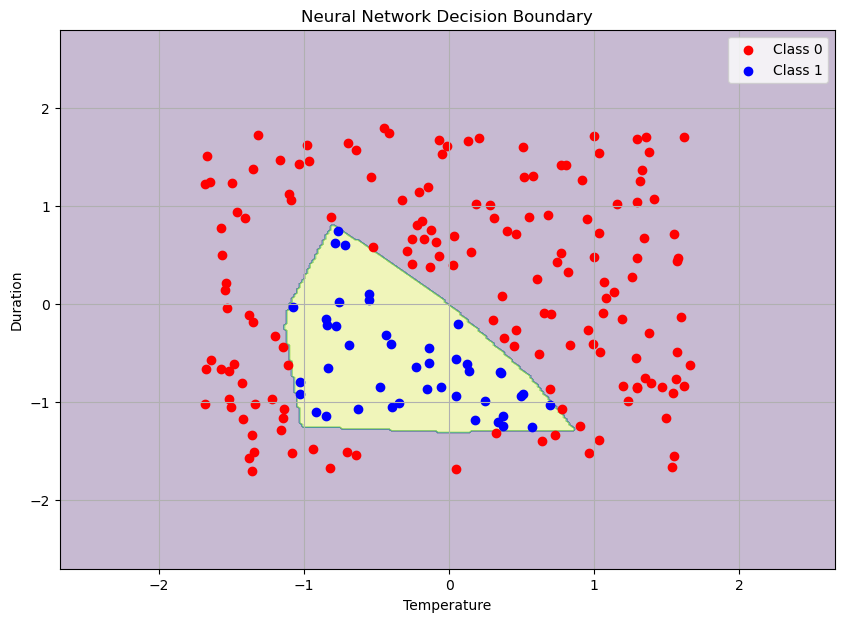

In [46]:
# -----------------------------
# DECISION BOUNDARY
# -----------------------------

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Create grid points
grid = np.c_[xx.ravel(), yy.ravel()]

# Forward propagation on grid
A = grid.T

for i in range(len(neurons_layer)):

    zz = w[i] @ A + b[i]

    if activation[i] == "sigmoid":
        A = sigmoid(zz)

    if activation[i] == "relu":
        A = relu(zz)

# Convert probabilities to classes
predictions = (A > 0.5).astype(int)

# Reshape to mesh shape
Z = predictions.reshape(xx.shape)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(10,7))

# Decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Original data points
plt.scatter(
    X[y.flatten()==0][:,0],
    X[y.flatten()==0][:,1],
    color='red',
    label='Class 0'
)

plt.scatter(
    X[y.flatten()==1][:,0],
    X[y.flatten()==1][:,1],
    color='blue',
    label='Class 1'
)

plt.xlabel("Temperature")
plt.ylabel("Duration")
plt.title("Neural Network Decision Boundary")
plt.legend()
plt.grid(True)

plt.show()